# 05 — Modelo sklearn (Random Forest + XGBoost)

Abordagem supervisionada com features de lag, diferente do Prophet que modela
tendência e sazonalidade diretamente, aqui o modelo aprende padrões a partir
das features construídas no notebook 03.

Modelos testados:
- **Random Forest Regressor**
- **XGBoost Regressor

Validação: walk-forward (mesmo protocolo do Prophet para comparação justa).  
Previsão futura: recursive forecast — usa a própria previsão como lag para os próximos passos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

PROC_DIR = Path('../data/processed')
FIG_DIR  = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

HORIZONTE = 24
N_TEST    = 12

# Features usadas no modelo — excluímos preco_real para evitar leakage do IPCA futuro
FEATURES = [
    'preco_lag1', 'preco_lag2', 'preco_lag3',
    'retorno_lag1',
    'cambio_lag1', 'cambio_lag3',
    'mes', 'trimestre', 'colheita',
    'sazonalidade_stl',
]
TARGET = 'preco_rs'

---
## 1. Funções auxiliares

In [2]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def avaliar(y_true, y_pred, nome):
    return {
        'modelo': nome,
        'MAPE':   round(mape(y_true, y_pred), 2),
        'RMSE':   round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAE':    round(mean_absolute_error(y_true, y_pred), 2),
    }


def walk_forward_sklearn(df, features, target, modelo_cls, modelo_params, n_test=12):
    """
    Walk-forward validation para modelos sklearn.
    Treina em histórico até t, prevê t+1.
    """
    preds, actuals = [], []
    for i in range(n_test):
        cutoff = len(df) - n_test + i
        train  = df.iloc[:cutoff]
        test   = df.iloc[cutoff:cutoff+1]

        X_train = train[features]
        y_train = train[target]
        X_test  = test[features]

        model = modelo_cls(**modelo_params)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)[0]

        preds.append(pred)
        actuals.append(test[target].values[0])

    return np.array(actuals), np.array(preds)


def recursive_forecast(df, features, target, modelo_cls, modelo_params, horizonte=24):
    """
    Previsão recursiva: treina no histórico completo, usa previsões anteriores
    como lags para os próximos passos.
    """
    model = modelo_cls(**modelo_params)
    model.fit(df[features], df[target])

    # Histórico como buffer para os lags
    hist = df.copy()
    forecasts = []
    ultima_data = hist['data'].max()

    for h in range(horizonte):
        proxima_data = ultima_data + pd.DateOffset(months=1)
        ultimo = hist.iloc[-1]

        row = {
            'preco_lag1':      hist['preco_rs'].iloc[-1],
            'preco_lag2':      hist['preco_rs'].iloc[-2],
            'preco_lag3':      hist['preco_rs'].iloc[-3],
            'retorno_lag1':    (hist['preco_rs'].iloc[-1] / hist['preco_rs'].iloc[-2] - 1) * 100,
            'cambio_lag1':     hist['usd_brl'].iloc[-1] if 'usd_brl' in hist.columns else ultimo['cambio_lag1'],
            'cambio_lag3':     hist['usd_brl'].iloc[-3] if 'usd_brl' in hist.columns else ultimo['cambio_lag3'],
            'mes':             proxima_data.month,
            'trimestre':       proxima_data.quarter,
            'colheita':        ultimo['colheita'],
            'sazonalidade_stl': ultimo['sazonalidade_stl'],
        }

        X_next = pd.DataFrame([row])[features]
        pred   = model.predict(X_next)[0]

        nova_linha = pd.DataFrame([{
            'data': proxima_data, 'preco_rs': pred,
            'usd_brl': ultimo.get('usd_brl', np.nan),
            'colheita': int(proxima_data.month in [3,4,5] if 'soja' in str(modelo_cls) else proxima_data.month in [2,3,7,8]),
            'sazonalidade_stl': ultimo['sazonalidade_stl'],
            **row
        }])
        hist = pd.concat([hist, nova_linha], ignore_index=True)
        forecasts.append({'ds': proxima_data, 'yhat': pred})
        ultima_data = proxima_data

    return pd.DataFrame(forecasts)


print('Funções definidas.')

Funções definidas.


---
## 2. Walk-forward validation

In [3]:
MODELOS = {
    'RandomForest': (
        RandomForestRegressor,
        {'n_estimators': 200, 'max_depth': 6, 'random_state': 42, 'n_jobs': -1}
    ),
    'XGBoost': (
        XGBRegressor,
        {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'random_state': 42, 'verbosity': 0}
    ),
}

resultados = {}

for commodity in ['soja', 'milho']:
    print(f'\n=== {commodity.upper()} ===')
    df = pd.read_parquet(PROC_DIR / f'features_{commodity}.parquet')
    resultados[commodity] = {'df': df, 'modelos': {}}

    for nome, (cls, params) in MODELOS.items():
        y_true, y_pred = walk_forward_sklearn(df, FEATURES, TARGET, cls, params, n_test=N_TEST)
        metr = avaliar(y_true, y_pred, nome)
        resultados[commodity]['modelos'][nome] = {
            'metricas': metr, 'y_true': y_true, 'y_pred': y_pred,
            'cls': cls, 'params': params,
        }
        print(f'  {nome:<15} MAPE: {metr["MAPE"]}% | RMSE: R${metr["RMSE"]} | MAE: R${metr["MAE"]}')


=== SOJA ===
  RandomForest    MAPE: 1.82% | RMSE: R$2.87 | MAE: R$2.3
  XGBoost         MAPE: 1.82% | RMSE: R$2.85 | MAE: R$2.31

=== MILHO ===
  RandomForest    MAPE: 2.77% | RMSE: R$2.18 | MAE: R$1.87
  XGBoost         MAPE: 3.12% | RMSE: R$2.34 | MAE: R$2.09


---
## 3. Real vs previsto — período de teste

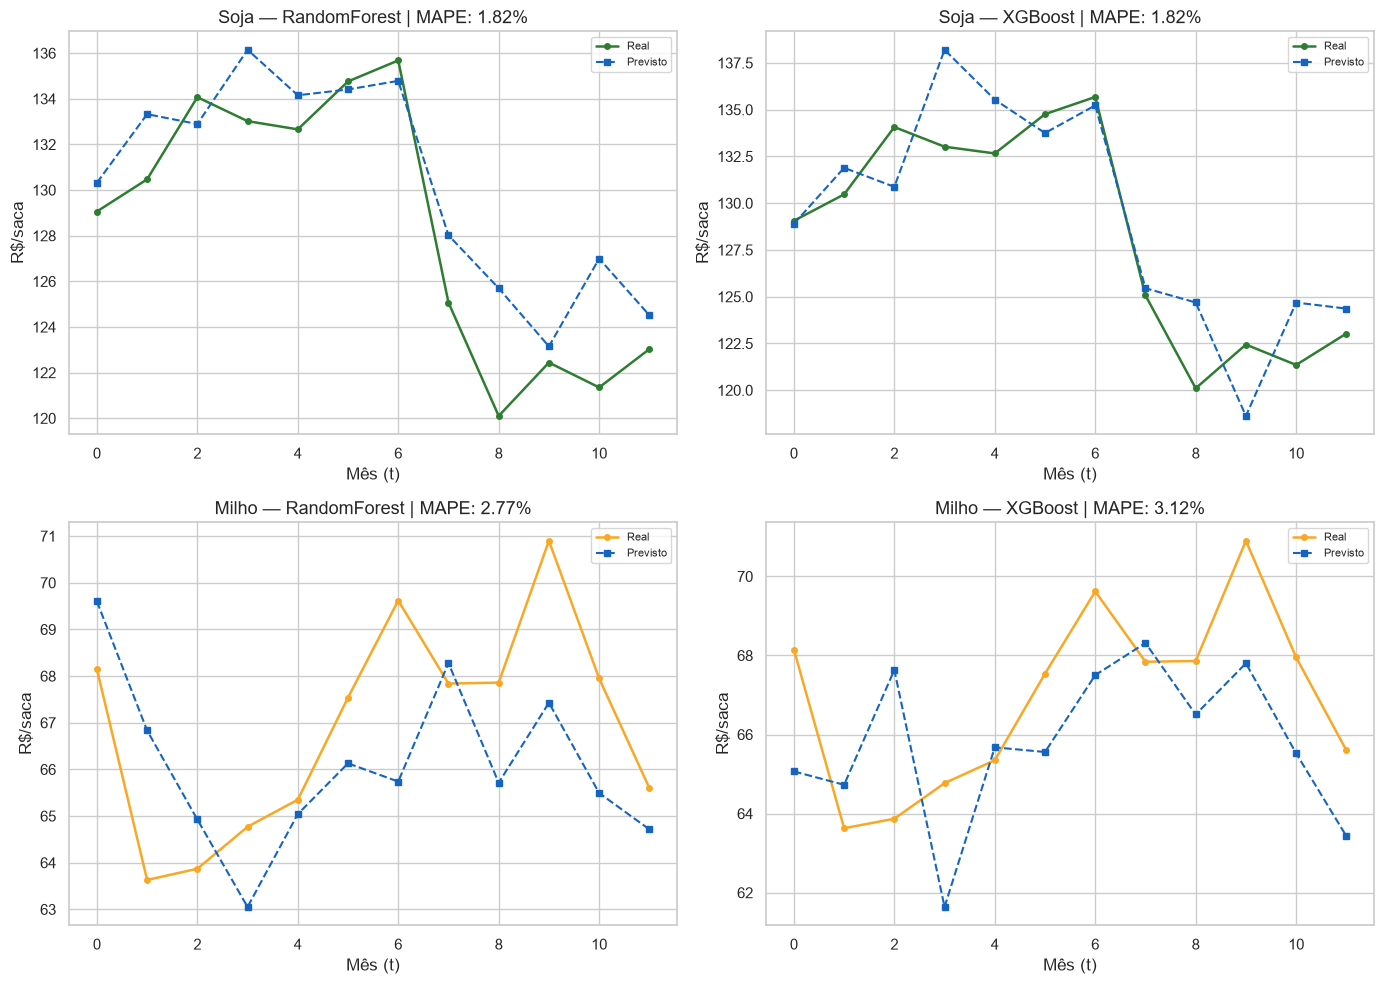

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, commodity in enumerate(['soja', 'milho']):
    cor = '#2e7d32' if commodity == 'soja' else '#f9a825'
    for col, nome in enumerate(['RandomForest', 'XGBoost']):
        ax = axes[row][col]
        r  = resultados[commodity]['modelos'][nome]
        m  = r['metricas']
        n  = len(r['y_true'])

        ax.plot(range(n), r['y_true'], color=cor,       linewidth=1.8, marker='o', markersize=4, label='Real')
        ax.plot(range(n), r['y_pred'], color='#1565c0', linewidth=1.5, marker='s', markersize=4, linestyle='--', label='Previsto')
        ax.set_title(f'{commodity.capitalize()} — {nome} | MAPE: {m["MAPE"]}%')
        ax.set_ylabel('R$/saca')
        ax.set_xlabel('Mês (t)')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'sklearn_teste.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Importância das features

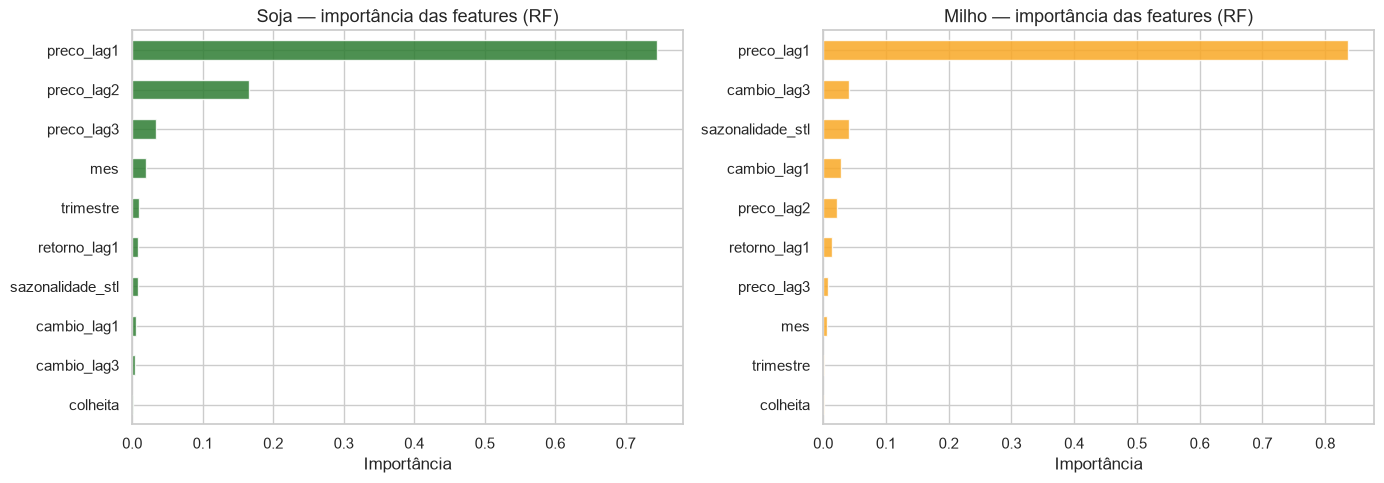

In [5]:
# Treina Random Forest no dataset completo para extrair importância das features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, commodity in zip(axes, ['soja', 'milho']):
    df = resultados[commodity]['df']
    cls, params = MODELOS['RandomForest']
    model = cls(**params)
    model.fit(df[FEATURES], df[TARGET])

    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    cor = '#2e7d32' if commodity == 'soja' else '#f9a825'
    imp.plot(kind='barh', ax=ax, color=cor, alpha=0.85)
    ax.set_title(f'{commodity.capitalize()} — importância das features (RF)')
    ax.set_xlabel('Importância')

plt.tight_layout()
plt.savefig(FIG_DIR / 'sklearn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Previsão futura — 24 meses

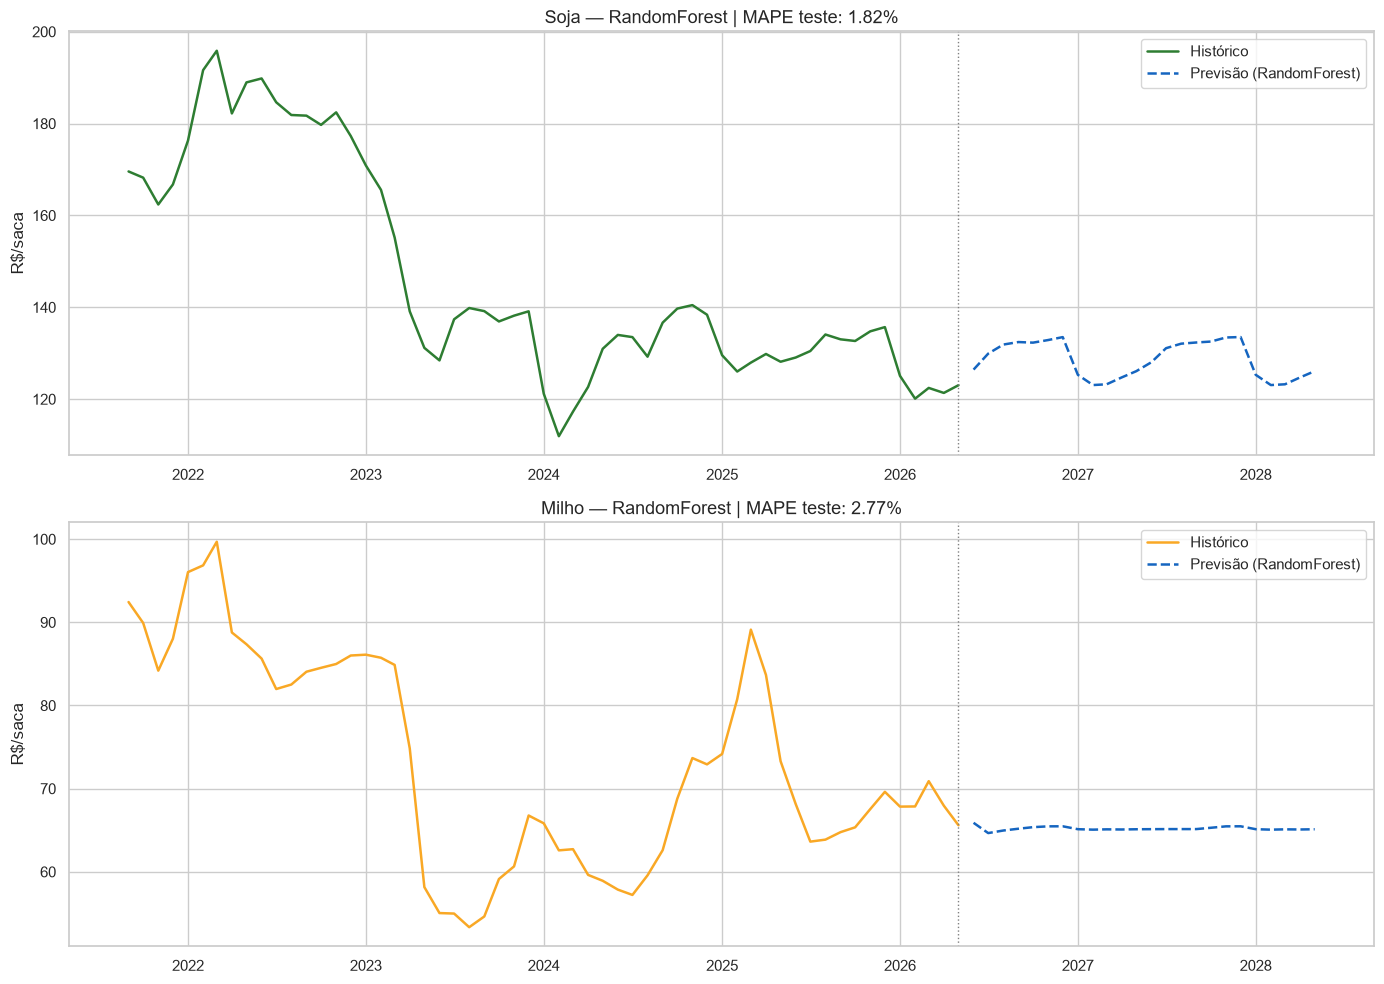

In [6]:
# Usa o melhor modelo por commodity (menor MAPE) para a previsão futura
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

for ax, (commodity, cor) in zip(axes, [('soja', '#2e7d32'), ('milho', '#f9a825')]):
    df = resultados[commodity]['df']

    # Seleciona melhor modelo
    melhor = min(
        resultados[commodity]['modelos'].items(),
        key=lambda x: x[1]['metricas']['MAPE']
    )
    nome_melhor, r_melhor = melhor
    cls, params = r_melhor['cls'], r_melhor['params']

    fc = recursive_forecast(df, FEATURES, TARGET, cls, params, horizonte=HORIZONTE)

    ax.plot(df['data'], df[TARGET], color=cor, linewidth=1.8, label='Histórico')
    ax.plot(fc['ds'], fc['yhat'], color='#1565c0', linewidth=1.8, linestyle='--', label=f'Previsão ({nome_melhor})')
    ax.axvline(df['data'].max(), color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{commodity.capitalize()} — {nome_melhor} | MAPE teste: {r_melhor["metricas"]["MAPE"]}%')
    ax.set_ylabel('R$/saca')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'sklearn_previsao.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Comparação final — Prophet vs sklearn

In [7]:
# Métricas Prophet salvas no notebook 04 — insere manualmente para comparação
prophet_metricas = {
    'soja':  {'MAPE': 7.65, 'RMSE': 11.49, 'MAE': 10.01},
    'milho': {'MAPE': 9.57, 'RMSE':  7.27, 'MAE':  6.43},
}

print('Comparação de modelos — walk-forward validation (12 meses, horizonte 1 mês)\n')

for commodity in ['soja', 'milho']:
    print(f'{commodity.upper()}')
    print(f'  {"Modelo":<18} {"MAPE":>8} {"RMSE":>10} {"MAE":>10}')
    print(f'  {"-"*48}')

    pm = prophet_metricas[commodity]
    print(f'  {"Prophet":<18} {pm["MAPE"]:>7.2f}% {"R$"+str(pm["RMSE"]):>10} {"R$"+str(pm["MAE"]):>10}')

    for nome, r in resultados[commodity]['modelos'].items():
        m = r['metricas']
        print(f'  {nome:<18} {m["MAPE"]:>7.2f}% {"R$"+str(m["RMSE"]):>10} {"R$"+str(m["MAE"]):>10}')
    print()

print('Figuras salvas em reports/figures/')

Comparação de modelos — walk-forward validation (12 meses, horizonte 1 mês)

SOJA
  Modelo                 MAPE       RMSE        MAE
  ------------------------------------------------
  Prophet               7.65%    R$11.49    R$10.01
  RandomForest          1.82%     R$2.87      R$2.3
  XGBoost               1.82%     R$2.85     R$2.31

MILHO
  Modelo                 MAPE       RMSE        MAE
  ------------------------------------------------
  Prophet               9.57%     R$7.27     R$6.43
  RandomForest          2.77%     R$2.18     R$1.87
  XGBoost               3.12%     R$2.34     R$2.09

Figuras salvas em reports/figures/
